# Analyse des Profils Étudiants
**Promotions 1, 2 et 3 — Données anonymisées**

Ce notebook analyse comment les caractéristiques des étudiants
(genre, filière d'entrée, type de bac, origine géographique)
influencent leur performance académique.



## 0. Chargement des données



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", "{:.2f}".format)

# --- Chargement ---
parcours = pd.read_csv("../data/parsed/parcours.csv")
profils  = pd.read_csv("../data/parsed/profils_anonymes.csv")

# Garder uniquement les promos 1, 2, 3
profils  = profils[profils["Promotion"].isin([1, 2, 3])].copy()
parcours = parcours[parcours["promo"].isin([1, 2, 3])].copy()

# Nettoyage des colonnes
profils = profils.rename(columns={
    "id_anon"      : "id",
    "Promotion"    : "promo",
    "Genre"        : "genre",
    "origine"      : "origine",
    "Licence/ Pisi": "filiere",
    "Bac"          : "bac"
})
profils["filiere"] = profils["filiere"].str.strip().str.lower()
profils["genre"]   = profils["genre"].str.strip().str.lower()
profils["bac"]     = profils["bac"].str.strip().str.lower()
profils["origine"] = profils["origine"].str.strip().str.lower()

# --- Jointure principale ---
df = parcours.merge(profils[["id","genre","filiere","bac","origine"]], on="id", how="left")

# Variable géographique simplifiée : Sfax vs reste de la Tunisie
df["region"] = df["origine"].apply(lambda x: "Sfax" if x == "sfax" else "Hors Sfax")

print(f"Étudiants dans l'analyse : {len(df)}")
print(f"Valeurs manquantes :\n{df[['genre','filiere','bac','origine']].isnull().sum()}")
df.head(3)


Étudiants dans l'analyse : 100
Valeurs manquantes :
genre      0
filiere    0
bac        6
origine    1
dtype: int64


,id,promo,moy_s1,moy_s2,moy_ann,rang,passage,genre,filiere,bac,origine,region
0,02d62872c6,2,15.22,15.84,15.53,2.00,Admis,m,pisi,math,sfax,Sfax
1,033574f04c,2,13.52,14.52,14.02,8.00,Admis,m,pisi,math,sfax,Sfax
2,033b92fdb6,3,11.97,12.56,12.27,22.00,Admis,m,pisi,math,sfax,Sfax


## 1. Vue d'ensemble des profils

Qui sont ces étudiants ? Répartition par genre, filière d'entrée et type de bac.



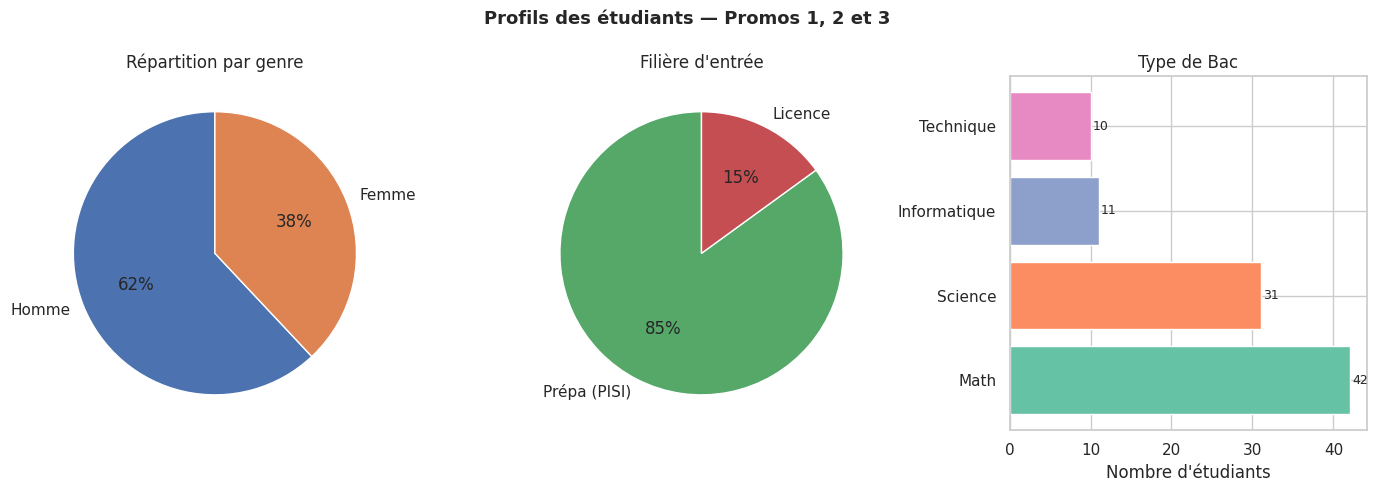

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Genre
genre_ct = df["genre"].value_counts()
genre_ct.index = ["Homme" if g == "m" else "Femme" for g in genre_ct.index]
axes[0].pie(genre_ct, labels=genre_ct.index, autopct="%1.0f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[0].set_title("Répartition par genre")

# Filière d'entrée
fil_ct = df["filiere"].value_counts()
fil_ct.index = ["Prépa (PISI)" if f == "pisi" else "Licence" for f in fil_ct.index]
axes[1].pie(fil_ct, labels=fil_ct.index, autopct="%1.0f%%",
            colors=["#55A868", "#C44E52"], startangle=90)
axes[1].set_title("Filière d'entrée")

# Type de bac
bac_ct = df["bac"].value_counts().dropna()
bac_ct.index = [b.capitalize() for b in bac_ct.index]
axes[2].barh(bac_ct.index, bac_ct.values, color=sns.color_palette("Set2", len(bac_ct)))
axes[2].set_title("Type de Bac")
axes[2].set_xlabel("Nombre d'étudiants")
for i, v in enumerate(bac_ct.values):
    axes[2].text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.suptitle("Profils des étudiants — Promos 1, 2 et 3", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 2. Genre et performance

Les femmes et les hommes ont-ils des résultats différents ?



/tmp/ipykernel_154351/1930173726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="genre_label", y="moy_ann",


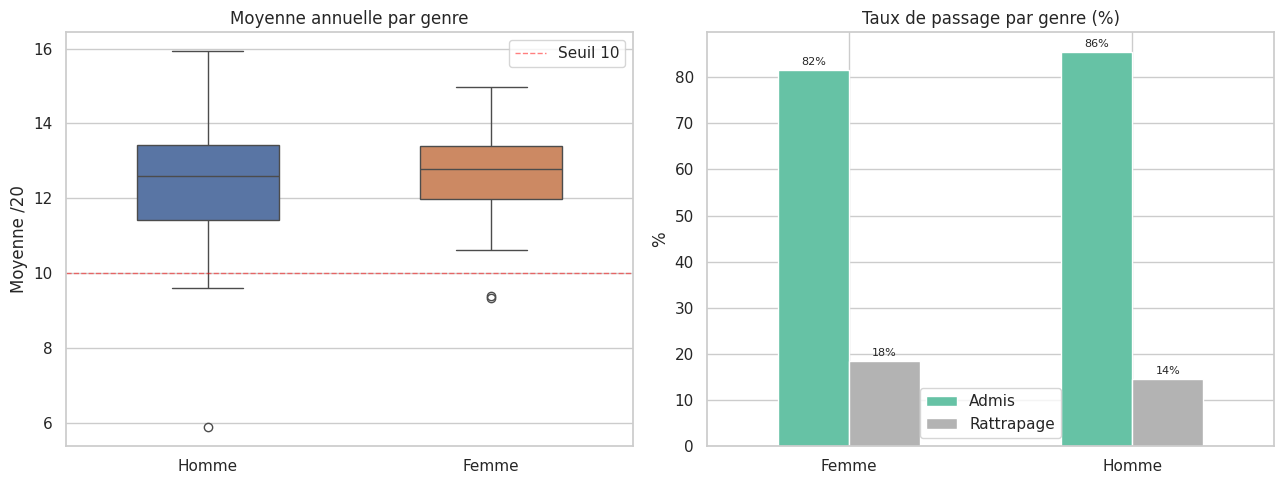

=== Statistiques par genre ===
             mean  std  count
genre_label                  
Femme       12.71 1.24     38
Homme       12.50 1.75     62

Test Mann-Whitney : p = 0.303  → pas de différence significative


In [3]:
# Remplacer m/f par des labels lisibles pour les graphiques
df["genre_label"] = df["genre"].map({"m": "Homme", "f": "Femme"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot des moyennes annuelles
sns.boxplot(data=df, x="genre_label", y="moy_ann",
            palette={"Homme": "#4C72B0", "Femme": "#DD8452"},
            width=0.5, ax=axes[0])
axes[0].axhline(10, color="red", lw=1, linestyle="--", alpha=0.5, label="Seuil 10")
axes[0].set(title="Moyenne annuelle par genre",
            xlabel="", ylabel="Moyenne /20")
axes[0].legend()

# Taux de rattrapage
passage_genre = (pd.crosstab(df["genre_label"], df["passage"], normalize="index") * 100).round(1)
passage_genre.plot.bar(ax=axes[1], colormap="Set2", edgecolor="white", rot=0)
axes[1].set(title="Taux de passage par genre (%)",
            xlabel="", ylabel="%")
axes[1].legend(title="")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f%%", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# Test statistique Mann-Whitney (non paramétrique)
hommes = df[df["genre"] == "m"]["moy_ann"].dropna()
femmes = df[df["genre"] == "f"]["moy_ann"].dropna()
stat, pval = stats.mannwhitneyu(hommes, femmes, alternative="two-sided")

print("=== Statistiques par genre ===")
print(df.groupby("genre_label")["moy_ann"].agg(["mean","std","count"]).round(2))
print(f"\nTest Mann-Whitney : p = {pval:.3f}  {'→ différence significative (p<0.05)' if pval < 0.05 else '→ pas de différence significative'}")


## 3. Filière d'entrée : Prépa (PISI) vs Licence

Les étudiants venant de prépa performent-ils mieux que ceux venant en licence ?



/tmp/ipykernel_154351/1627981903.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="filiere_label", y="moy_ann",


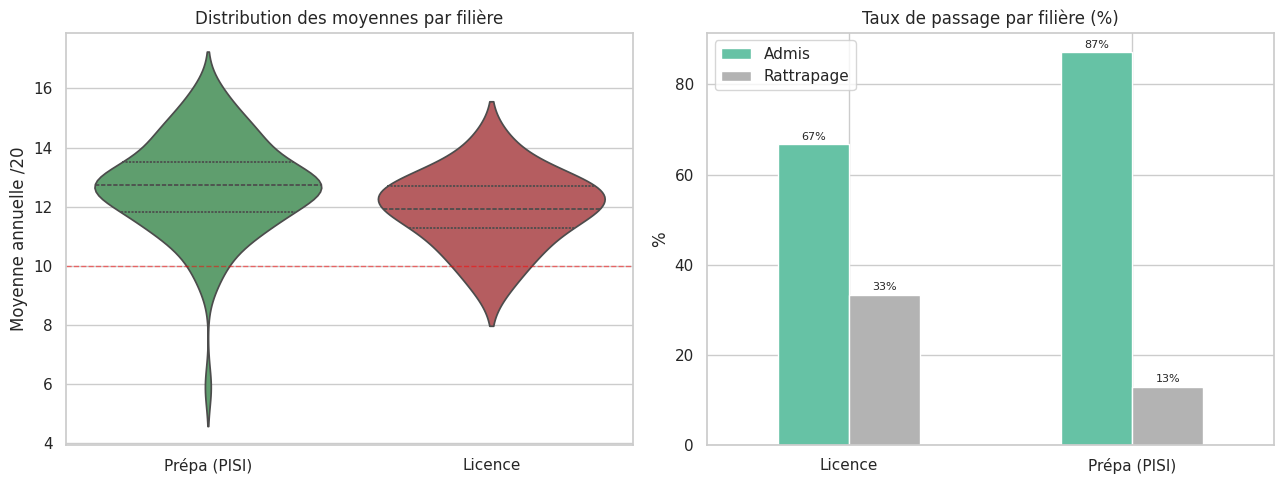

=== Statistiques par filière d'entrée ===
               mean  std  count
filiere_label                  
Licence       11.92 1.23     15
Prépa (PISI)  12.70 1.60     85

Test Mann-Whitney : p = 0.039  → différence significative (p<0.05)

=== Moyenne annuelle par filière et par promo ===
filiere_label  Licence  Prépa (PISI)
promo                               
1                11.34         12.41
2                12.02         12.63
3                12.19         13.11


In [4]:
df["filiere_label"] = df["filiere"].map({"pisi": "Prépa (PISI)", "licence": "Licence"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution complète
sns.violinplot(data=df, x="filiere_label", y="moy_ann",
               palette={"Prépa (PISI)": "#55A868", "Licence": "#C44E52"},
               inner="quartile", ax=axes[0])
axes[0].axhline(10, color="red", lw=1, linestyle="--", alpha=0.5)
axes[0].set(title="Distribution des moyennes par filière",
            xlabel="", ylabel="Moyenne annuelle /20")

# Passage
passage_fil = (pd.crosstab(df["filiere_label"], df["passage"], normalize="index") * 100).round(1)
passage_fil.plot.bar(ax=axes[1], colormap="Set2", edgecolor="white", rot=0)
axes[1].set(title="Taux de passage par filière (%)", xlabel="", ylabel="%")
axes[1].legend(title="")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f%%", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# Test statistique
pisi    = df[df["filiere"] == "pisi"]["moy_ann"].dropna()
licence = df[df["filiere"] == "licence"]["moy_ann"].dropna()
stat, pval = stats.mannwhitneyu(pisi, licence, alternative="two-sided")

print("=== Statistiques par filière d'entrée ===")
print(df.groupby("filiere_label")["moy_ann"].agg(["mean","std","count"]).round(2))
print(f"\nTest Mann-Whitney : p = {pval:.3f}  {'→ différence significative (p<0.05)' if pval < 0.05 else '→ pas de différence significative'}")

# Évolution par promo : est-ce que l'écart se creuse ou se réduit ?
print("\n=== Moyenne annuelle par filière et par promo ===")
print(df.groupby(["promo","filiere_label"])["moy_ann"].mean().unstack().round(2))


## 4. Type de Bac et performance

Le bac de mathématiques donne-t-il un avantage en école d'ingénieur ?



/tmp/ipykernel_154351/32248092.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.dropna(subset=["bac"]),


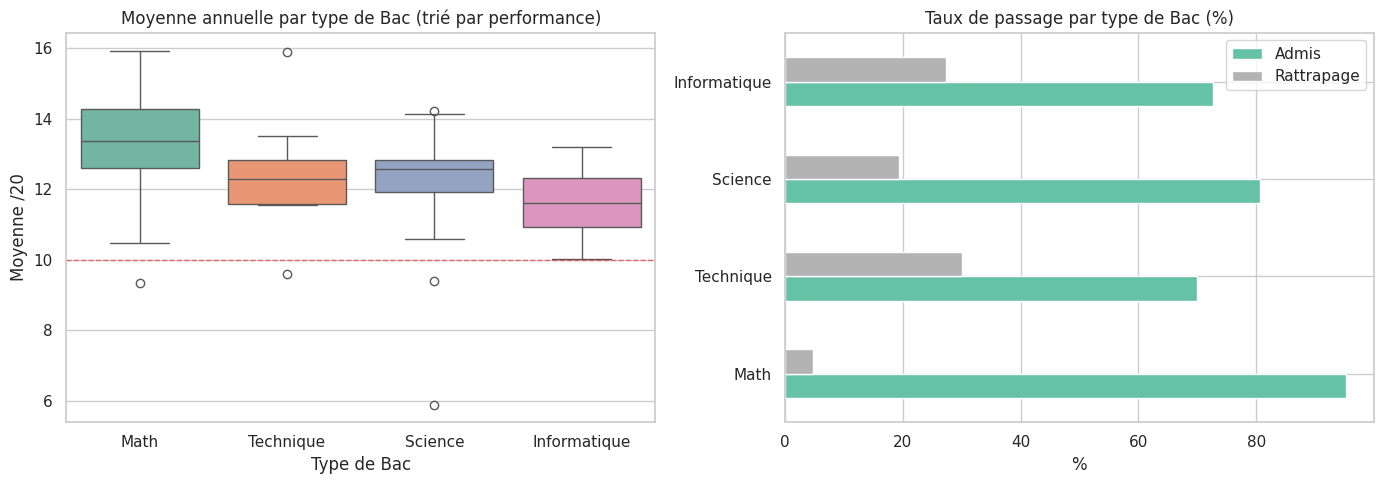

=== Statistiques par type de Bac ===
              mean  std  count
bac_label                     
Math         13.30 1.51     42
Technique    12.39 1.63     10
Science      12.21 1.51     31
Informatique 11.57 1.01     11

Test Kruskal-Wallis (tous bacs) : p = 0.000  → différence significative (p<0.05)


In [5]:
# Ordre logique par performance décroissante
bac_order = df.groupby("bac")["moy_ann"].mean().dropna().sort_values(ascending=False).index.tolist()
bac_labels = {b: b.capitalize() for b in bac_order}
df["bac_label"] = df["bac"].map(bac_labels)
bac_label_order = [bac_labels[b] for b in bac_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot trié par moyenne
sns.boxplot(data=df.dropna(subset=["bac"]),
            x="bac_label", y="moy_ann",
            order=bac_label_order,
            palette="Set2", ax=axes[0])
axes[0].axhline(10, color="red", lw=1, linestyle="--", alpha=0.5)
axes[0].set(title="Moyenne annuelle par type de Bac (trié par performance)",
            xlabel="Type de Bac", ylabel="Moyenne /20")

# Taux de rattrapage par bac
passage_bac = (pd.crosstab(df["bac_label"], df["passage"], normalize="index") * 100).round(1)
passage_bac = passage_bac.loc[[b for b in bac_label_order if b in passage_bac.index]]
passage_bac.plot.barh(ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set(title="Taux de passage par type de Bac (%)", xlabel="%", ylabel="")
axes[1].legend(title="")

plt.tight_layout()
plt.show()

print("=== Statistiques par type de Bac ===")
bac_stats = df.groupby("bac_label")["moy_ann"].agg(["mean","std","count"]).round(2)
bac_stats = bac_stats.sort_values("mean", ascending=False)
print(bac_stats)

# Test Kruskal-Wallis (comparaison multi-groupes)
groupes = [df[df["bac"] == b]["moy_ann"].dropna() for b in bac_order if len(df[df["bac"]==b]) > 1]
stat, pval = stats.kruskal(*groupes)
print(f"\nTest Kruskal-Wallis (tous bacs) : p = {pval:.3f}  {'→ différence significative (p<0.05)' if pval < 0.05 else '→ pas de différence significative'}")


## 5. Origine géographique

Les étudiants de Sfax vs ceux venant d'autres régions de Tunisie.



/tmp/ipykernel_154351/3410800604.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="region", y="moy_ann",


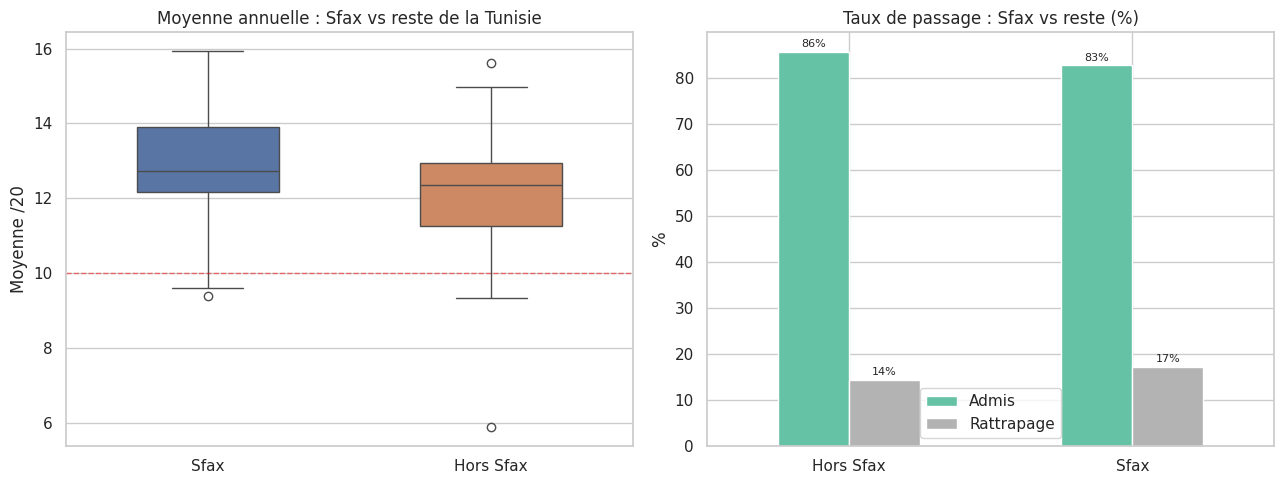

=== Sfax vs Hors Sfax ===
           mean  std  count
region                     
Hors Sfax 12.20 1.66     42
Sfax      12.86 1.46     58

Test Mann-Whitney : p = 0.041  → différence significative (p<0.05)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sfax vs hors Sfax
sns.boxplot(data=df, x="region", y="moy_ann",
            palette={"Sfax": "#4C72B0", "Hors Sfax": "#DD8452"},
            width=0.5, ax=axes[0])
axes[0].axhline(10, color="red", lw=1, linestyle="--", alpha=0.5)
axes[0].set(title="Moyenne annuelle : Sfax vs reste de la Tunisie",
            xlabel="", ylabel="Moyenne /20")

# Taux de passage
passage_region = (pd.crosstab(df["region"], df["passage"], normalize="index") * 100).round(1)
passage_region.plot.bar(ax=axes[1], colormap="Set2", edgecolor="white", rot=0)
axes[1].set(title="Taux de passage : Sfax vs reste (%)", xlabel="", ylabel="%")
axes[1].legend(title="")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f%%", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# Test statistique
sfax     = df[df["region"] == "Sfax"]["moy_ann"].dropna()
horssfax = df[df["region"] == "Hors Sfax"]["moy_ann"].dropna()
stat, pval = stats.mannwhitneyu(sfax, horssfax, alternative="two-sided")

print("=== Sfax vs Hors Sfax ===")
print(df.groupby("region")["moy_ann"].agg(["mean","std","count"]).round(2))
print(f"\nTest Mann-Whitney : p = {pval:.3f}  {'→ différence significative (p<0.05)' if pval < 0.05 else '→ pas de différence significative'}")


## 6. Carte des origines — top villes



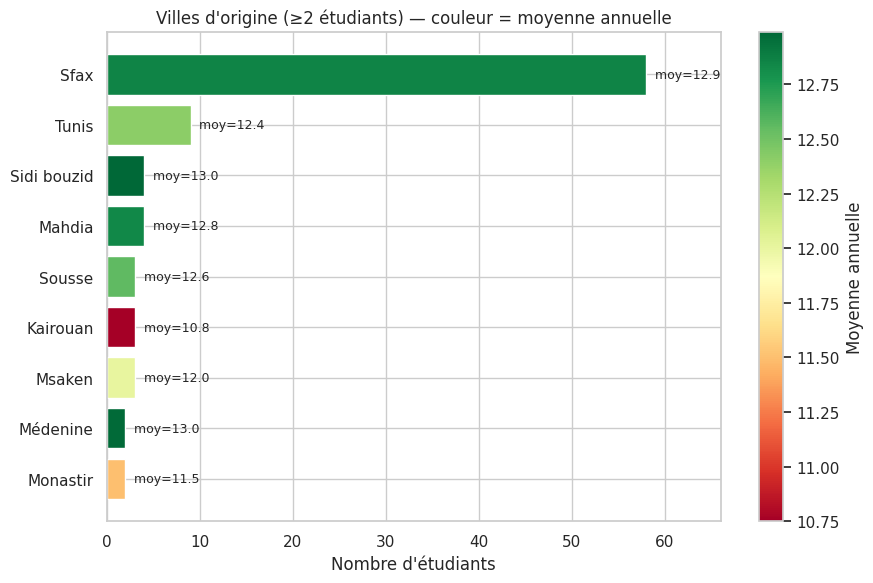

In [7]:
# Nombre d'étudiants et moyenne par ville (villes avec ≥ 2 étudiants)
ville_stats = (df.groupby("origine")["moy_ann"]
               .agg(["mean", "count"])
               .rename(columns={"mean": "moy_ann", "count": "n"})
               .query("n >= 2")
               .sort_values("n", ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(ville_stats.index.str.capitalize(),
               ville_stats["n"],
               color=plt.cm.RdYlGn(
                   (ville_stats["moy_ann"] - ville_stats["moy_ann"].min()) /
                   (ville_stats["moy_ann"].max() - ville_stats["moy_ann"].min())
               ))
# Annotations : moyenne
for i, (_, row) in enumerate(ville_stats.iterrows()):
    ax.text(row["n"] + 0.1, i, f'  moy={row["moy_ann"]:.1f}', va="center", fontsize=9)

ax.set(title="Villes d'origine (≥2 étudiants) — couleur = moyenne annuelle",
       xlabel="Nombre d'étudiants")
ax.set_xlim(0, ville_stats["n"].max() + 8)

import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = plt.cm.ScalarMappable(cmap="RdYlGn",
     norm=mcolors.Normalize(vmin=ville_stats["moy_ann"].min(),
                             vmax=ville_stats["moy_ann"].max()))
plt.colorbar(sm, ax=ax, label="Moyenne annuelle")
plt.tight_layout()
plt.show()


## 7. Croisement : Filière × Genre × Performance

Est-ce que l'effet filière est identique pour les hommes et les femmes ?



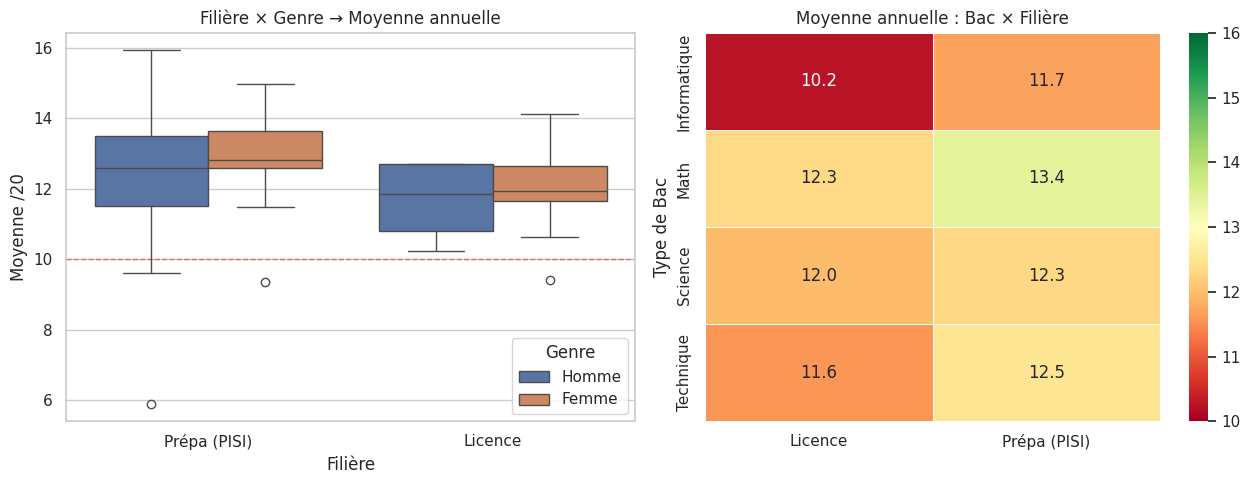

=== Moyenne par filière et genre ===
genre_label    Femme  Homme
filiere_label              
Licence        12.02  11.66
Prépa (PISI)   12.99  12.56


In [8]:
df_cross = df.dropna(subset=["filiere","genre"])
df_cross["filiere_label"] = df_cross["filiere"].map({"pisi": "Prépa (PISI)", "licence": "Licence"})
df_cross["genre_label"]   = df_cross["genre"].map({"m": "Homme", "f": "Femme"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot croisé
sns.boxplot(data=df_cross, x="filiere_label", y="moy_ann",
            hue="genre_label",
            palette={"Homme": "#4C72B0", "Femme": "#DD8452"},
            ax=axes[0])
axes[0].axhline(10, color="red", lw=1, linestyle="--", alpha=0.5)
axes[0].set(title="Filière × Genre → Moyenne annuelle",
            xlabel="Filière", ylabel="Moyenne /20")
axes[0].legend(title="Genre")

# Heatmap des moyennes : bac × filière
heatmap_data = df.dropna(subset=["bac","filiere"]).groupby(["bac","filiere"])["moy_ann"].mean().unstack()
heatmap_data.columns = ["Licence", "Prépa (PISI)"]
heatmap_data.index = [b.capitalize() for b in heatmap_data.index]
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn",
            vmin=10, vmax=16, ax=axes[1], linewidths=0.5)
axes[1].set(title="Moyenne annuelle : Bac × Filière", xlabel="", ylabel="Type de Bac")

plt.tight_layout()
plt.show()

# Tableau résumé
print("=== Moyenne par filière et genre ===")
print(df_cross.groupby(["filiere_label","genre_label"])["moy_ann"].mean().unstack().round(2))


## 8. Évolution des profils par promotion

La composition des promos change-t-elle d'une année à l'autre ?



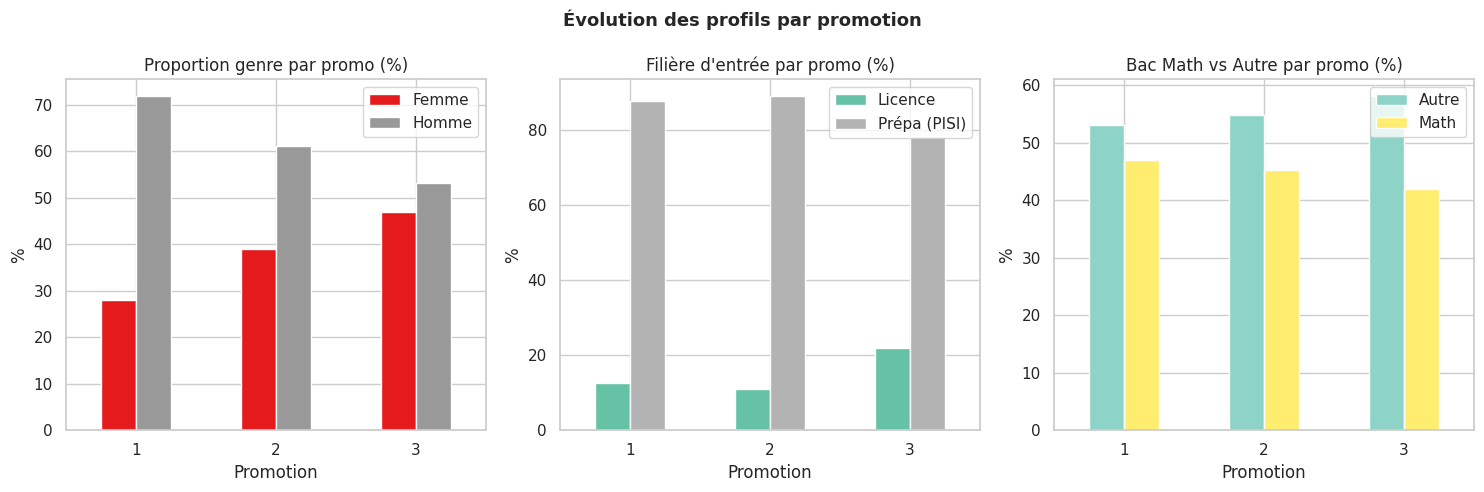

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Proportion de femmes par promo
genre_promo = (pd.crosstab(df["promo"], df["genre_label"], normalize="index") * 100).round(1)
genre_promo.plot.bar(ax=axes[0], colormap="Set1", edgecolor="white", rot=0)
axes[0].set(title="Proportion genre par promo (%)", xlabel="Promotion", ylabel="%")
axes[0].legend(title="")

# Proportion de licence par promo
fil_promo = (pd.crosstab(df["promo"], df["filiere_label"], normalize="index") * 100).round(1)
fil_promo.plot.bar(ax=axes[1], colormap="Set2", edgecolor="white", rot=0)
axes[1].set(title="Filière d'entrée par promo (%)", xlabel="Promotion", ylabel="%")
axes[1].legend(title="")

# Proportion bac math par promo
df["bac_math"] = df["bac"].apply(lambda x: "Math" if x == "math" else "Autre" if pd.notna(x) else np.nan)
bac_promo = (pd.crosstab(df["promo"], df["bac_math"], normalize="index") * 100).round(1)
if "Math" in bac_promo.columns:
    bac_promo.plot.bar(ax=axes[2], colormap="Set3", edgecolor="white", rot=0)
axes[2].set(title="Bac Math vs Autre par promo (%)", xlabel="Promotion", ylabel="%")
axes[2].legend(title="")

plt.suptitle("Évolution des profils par promotion", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Récapitulatif — Tableau de synthèse



In [10]:
recap = pd.DataFrame({
    "Variable": ["Genre (H vs F)", "Filière (PISI vs Licence)",
                  "Bac Math (vs autres)", "Origine (Sfax vs hors)"],
    "Moy PISI/Math/Sfax/H": [
        df[df["genre"]=="m"]["moy_ann"].mean(),
        df[df["filiere"]=="pisi"]["moy_ann"].mean(),
        df[df["bac"]=="math"]["moy_ann"].mean(),
        df[df["region"]=="Sfax"]["moy_ann"].mean()
    ],
    "Moy Licence/Autre/HorsSfax/F": [
        df[df["genre"]=="f"]["moy_ann"].mean(),
        df[df["filiere"]=="licence"]["moy_ann"].mean(),
        df[df["bac"]!="math"]["moy_ann"].dropna().mean(),
        df[df["region"]=="Hors Sfax"]["moy_ann"].mean()
    ],
}).round(2)
recap["Écart"] = (recap.iloc[:,1] - recap.iloc[:,2]).round(2)

print("=== SYNTHÈSE DES ÉCARTS DE PERFORMANCE ===\n")
print(recap.to_string(index=False))
print("\nNote : un écart positif signifie que le premier groupe performe mieux.")


=== SYNTHÈSE DES ÉCARTS DE PERFORMANCE ===

                 Variable  Moy PISI/Math/Sfax/H  Moy Licence/Autre/HorsSfax/F  Écart
           Genre (H vs F)                 12.50                         12.71  -0.21
Filière (PISI vs Licence)                 12.70                         11.92   0.78
     Bac Math (vs autres)                 13.30                         12.06   1.24
   Origine (Sfax vs hors)                 12.86                         12.20   0.66

Note : un écart positif signifie que le premier groupe performe mieux.


## 10. Qui sont les étudiants en difficulté ?

Profil-type des étudiants en rattrapage.



Étudiants en rattrapage : 16 (16%)

--- Profil des étudiants en RATTRAPAGE ---
  Genre      : {'Homme': 9, 'Femme': 7}
  Filière    : {'pisi': 11, 'licence': 5}
  Bac        : {'science': 6, 'informatique': 3, 'technique': 3, 'math': 2}
  Région     : {'Sfax': 10, 'Hors Sfax': 6}
  Moy S1     : 10.59  (admis : 12.89)
  Moy S2     : 10.45  (admis : 13.05)


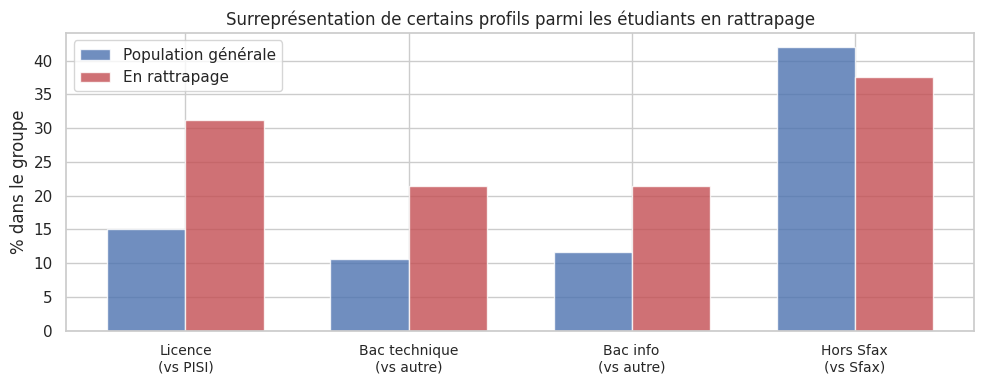

In [11]:
rattrapage = df[df["passage"] == "Rattrapage"]
admis      = df[df["passage"] == "Admis"]

print(f"Étudiants en rattrapage : {len(rattrapage)} ({len(rattrapage)/len(df)*100:.0f}%)\n")

print("--- Profil des étudiants en RATTRAPAGE ---")
print(f"  Genre      : {rattrapage['genre_label'].value_counts().to_dict()}")
print(f"  Filière    : {rattrapage['filiere'].value_counts().to_dict()}")
print(f"  Bac        : {rattrapage['bac'].value_counts().to_dict()}")
print(f"  Région     : {rattrapage['region'].value_counts().to_dict()}")
print(f"  Moy S1     : {rattrapage['moy_s1'].mean():.2f}  (admis : {admis['moy_s1'].mean():.2f})")
print(f"  Moy S2     : {rattrapage['moy_s2'].mean():.2f}  (admis : {admis['moy_s2'].mean():.2f})")

# Visualisation du profil en rattrapage
fig, ax = plt.subplots(figsize=(10, 4))
risk_factors = {
    "Licence\n(vs PISI)":
        len(rattrapage[rattrapage["filiere"]=="licence"]) / len(rattrapage[rattrapage["filiere"].notna()]) * 100,
    "Bac technique\n(vs autre)":
        len(rattrapage[rattrapage["bac"]=="technique"]) / max(len(rattrapage[rattrapage["bac"].notna()]),1) * 100,
    "Bac info\n(vs autre)":
        len(rattrapage[rattrapage["bac"]=="informatique"]) / max(len(rattrapage[rattrapage["bac"].notna()]),1) * 100,
    "Hors Sfax\n(vs Sfax)":
        len(rattrapage[rattrapage["region"]=="Hors Sfax"]) / len(rattrapage) * 100,
}
general = {
    "Licence\n(vs PISI)":
        len(df[df["filiere"]=="licence"]) / len(df[df["filiere"].notna()]) * 100,
    "Bac technique\n(vs autre)":
        len(df[df["bac"]=="technique"]) / len(df[df["bac"].notna()]) * 100,
    "Bac info\n(vs autre)":
        len(df[df["bac"]=="informatique"]) / len(df[df["bac"].notna()]) * 100,
    "Hors Sfax\n(vs Sfax)":
        len(df[df["region"]=="Hors Sfax"]) / len(df) * 100,
}

x = np.arange(len(risk_factors))
w = 0.35
ax.bar(x - w/2, general.values(),    w, label="Population générale", color="#4C72B0", alpha=0.8)
ax.bar(x + w/2, risk_factors.values(), w, label="En rattrapage",     color="#C44E52", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(risk_factors.keys(), fontsize=10)
ax.set_ylabel("% dans le groupe")
ax.set_title("Surreprésentation de certains profils parmi les étudiants en rattrapage")
ax.legend()
plt.tight_layout()
plt.show()
